# 05 — Final comparison table and figure

**Goal.** One table and one figure that summarise the preliminary experiment for the
consultation.

All numbers are 10×5-fold cross-validation on the 241 training documents. Confidence intervals
are bootstrap percentiles over the documents, which is what makes the comparison honest: with
a sample this small, several representations are genuinely indistinguishable and the figure
should show that rather than hide it behind a ranking.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

res = pd.read_csv("outputs/baseline_results.csv")
oof = pd.read_csv("outputs/baseline_oof_probs.csv")
y = oof.pop("label").values
print(f"{len(res)} representations, {len(y)} documents")

7 representations, 241 documents


## Bootstrap confidence intervals

We resample the 241 documents with replacement 2000 times and recompute AUC each time. The
2.5th and 97.5th percentiles give a 95% interval. The width of that interval is the honest
measure of how much we can conclude.

In [2]:
def bootstrap_auc_ci(y_true, prob, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    vals = []
    for _ in range(n_boot):
        b = rng.choice(idx, len(idx), replace=True)
        if len(np.unique(y_true[b])) < 2:
            continue
        vals.append(roc_auc_score(y_true[b], prob[b]))
    return np.percentile(vals, [2.5, 97.5])

ci = {}
for name in oof.columns:
    if name == "Majority class":          # constant prediction — AUC undefined
        ci[name] = (np.nan, np.nan)
    else:
        lo, hi = bootstrap_auc_ci(y, oof[name].values)
        ci[name] = (lo, hi)

res["auc_lo"] = res.representation.map(lambda n: ci[n][0])
res["auc_hi"] = res.representation.map(lambda n: ci[n][1])

## The table

In [3]:
table = res[["representation", "auc", "auc_lo", "auc_hi",
             "macro_f1", "f1_positive", "accuracy", "balanced_accuracy"]].copy()
table.columns = ["Representation", "AUC", "CI low", "CI high",
                 "Macro F1", "F1 (positive)", "Accuracy", "Balanced acc."]
table = table.sort_values("AUC", ascending=False).reset_index(drop=True)

print(table.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
table.to_csv("outputs/final_comparison.csv", index=False)

        Representation   AUC  CI low  CI high  Macro F1  F1 (positive)  Accuracy  Balanced acc.
   TF-IDF char 3-5gram 0.868   0.815    0.915     0.758          0.652     0.805          0.753
   TF-IDF word 1-2gram 0.842   0.784    0.897     0.760          0.652     0.809          0.752
Surface + LLM features 0.757   0.686    0.826     0.693          0.579     0.734          0.703
    Surface statistics 0.742   0.672    0.806     0.644          0.543     0.672          0.672
 LLM features (logreg) 0.694   0.616    0.766     0.620          0.491     0.664          0.632
Transcript length only 0.693   0.615    0.764     0.606          0.508     0.631          0.639
        Majority class 0.500     NaN      NaN     0.415          0.000     0.710          0.500


**How to read this table.**

* The **majority class** row has accuracy 0.71 and balanced accuracy 0.50. That gap is the
  single clearest argument for not reporting accuracy on its own.
* Compare every row against **transcript length only**. A representation that does not clearly
  beat one number — how many words the person said — is not yet earning its keep.
* Where confidence intervals overlap substantially, the ranking between those rows is not
  supported by the data. Say "indistinguishable", not "slightly better".

## The figure

A dot for the point estimate, a whisker for the 95% interval. Dotted line at 0.5 = chance.
The dashed line marks the AUC of transcript length alone: anything to the left of it carries
no more information than a word count.

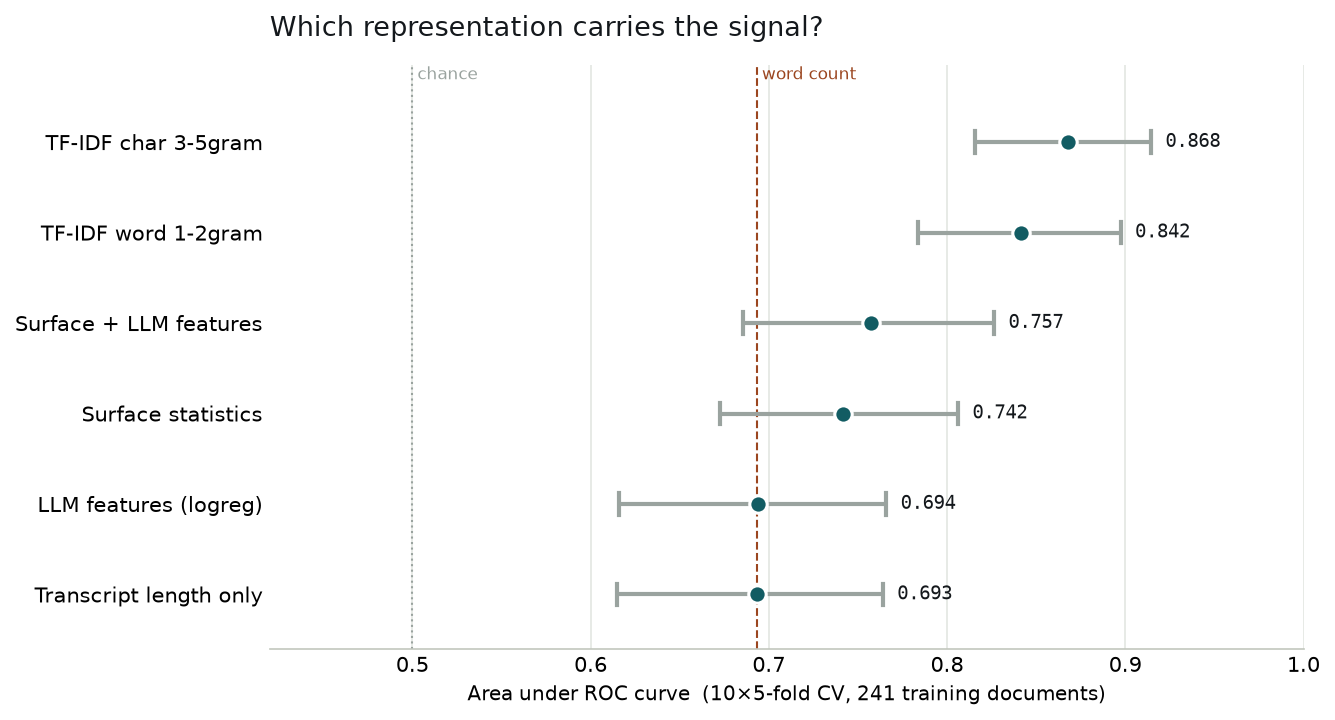

In [4]:
plot_df = (res[res.representation != "Majority class"]
           .sort_values("auc")
           .reset_index(drop=True))

length_auc = float(res.loc[res.representation == "Transcript length only", "auc"].iloc[0])

INK, ACCENT, MUTED, WARN = "#14181C", "#125C63", "#9AA39F", "#9B4620"

fig, ax = plt.subplots(figsize=(9, 0.55 * len(plot_df) + 1.6), dpi=150)

for i, r in plot_df.iterrows():
    ax.plot([r.auc_lo, r.auc_hi], [i, i], color=MUTED, lw=2, solid_capstyle="butt", zorder=2)
    ax.plot([r.auc_lo, r.auc_lo], [i - .12, i + .12], color=MUTED, lw=2, zorder=2)
    ax.plot([r.auc_hi, r.auc_hi], [i - .12, i + .12], color=MUTED, lw=2, zorder=2)
    ax.scatter(r.auc, i, s=70, color=ACCENT, zorder=3, edgecolor="white", linewidth=1.5)
    ax.text(r.auc_hi + 0.008, i, f"{r.auc:.3f}", va="center", ha="left",
            fontsize=9, color=INK, family="monospace")

ax.axvline(0.5, color=MUTED, ls=":", lw=1, zorder=1)
ax.text(0.5, len(plot_df) - 0.35, " chance", fontsize=8, color=MUTED, va="bottom")
ax.axvline(length_auc, color=WARN, ls="--", lw=1, zorder=1)
ax.text(length_auc, len(plot_df) - 0.35, " word count", fontsize=8, color=WARN, va="bottom")

ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.representation, fontsize=10)
ax.set_xlabel("Area under ROC curve  (10×5-fold CV, 241 training documents)", fontsize=9.5)
ax.set_xlim(0.42, 1.0)
ax.set_ylim(-0.6, len(plot_df) - 0.15)
ax.grid(axis="x", color="#E3E6E1", lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#C2C7BE")
ax.tick_params(length=0)
ax.set_title("Which representation carries the signal?", fontsize=13, loc="left", pad=14, color=INK)

plt.tight_layout()
plt.savefig("outputs/comparison.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Metric-by-metric view

The same models under all four metrics, so nobody has to take the AUC ranking on trust.

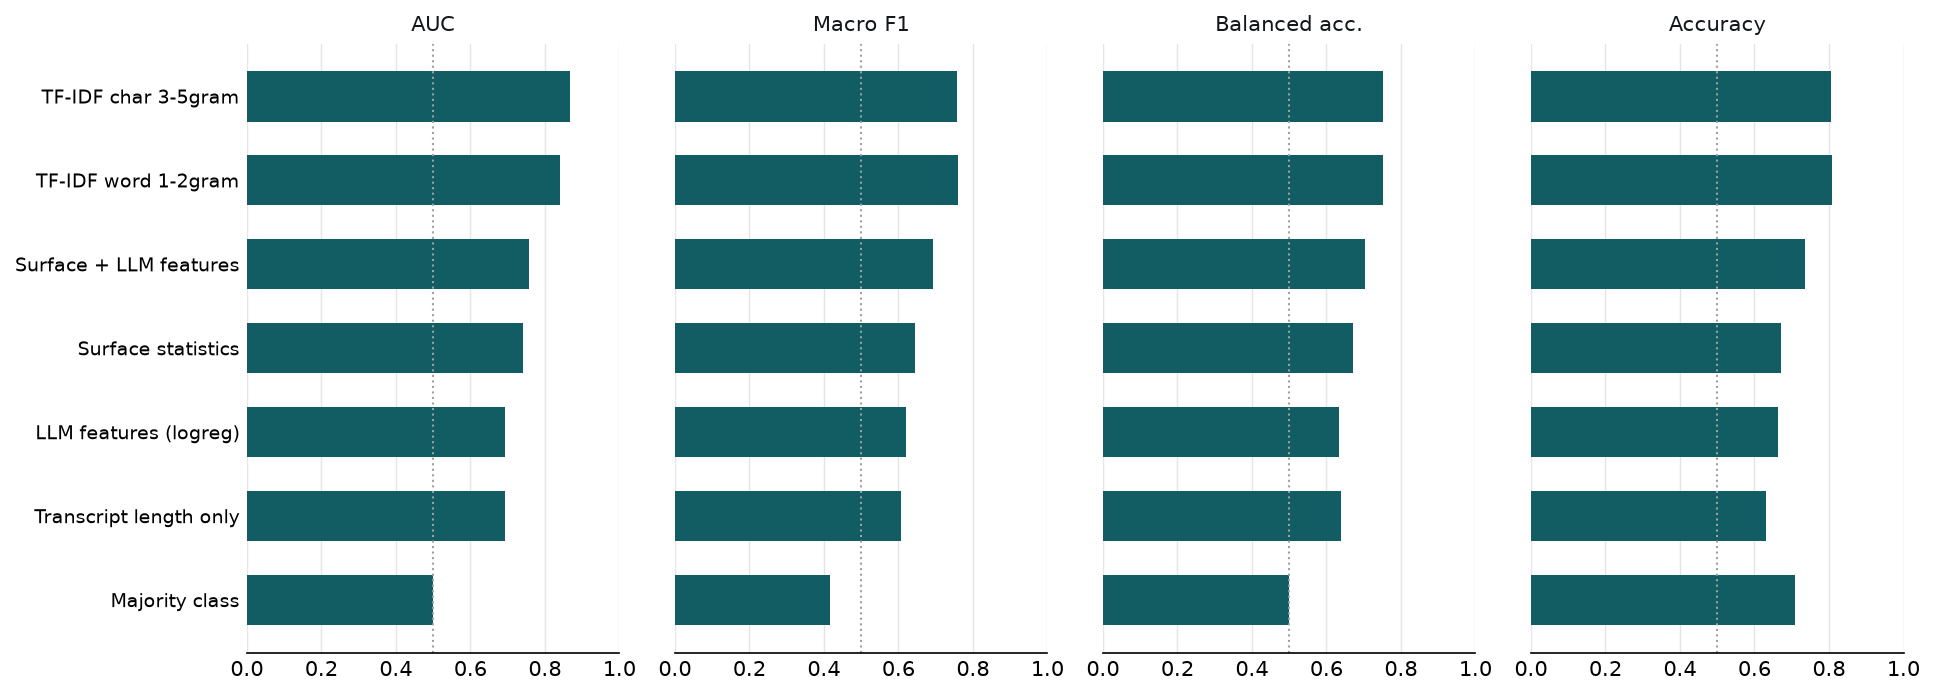

In [5]:
melt = (table.set_index("Representation")[["AUC", "Macro F1", "Balanced acc.", "Accuracy"]]
        .sort_values("AUC"))
fig, axes = plt.subplots(1, 4, figsize=(13, 0.42 * len(melt) + 1.8), dpi=150, sharey=True)
for ax, col in zip(axes, melt.columns):
    ax.barh(range(len(melt)), melt[col], color=ACCENT, height=0.6)
    ax.set_title(col, fontsize=10, color=INK)
    ax.set_xlim(0, 1)
    ax.axvline(0.5, color=MUTED, ls=":", lw=1)
    ax.grid(axis="x", color="#E3E6E1", lw=0.7)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0)
axes[0].set_yticks(range(len(melt)))
axes[0].set_yticklabels(melt.index, fontsize=9)
plt.tight_layout()
plt.savefig("outputs/comparison_metrics.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### Summary — the story in three sentences

1. The current LLM feature representation does not clearly beat counting the words in the
   transcript, even though several of its individual features are statistically associated
   with diagnosis.
2. A plain character n-gram model does much better, which shows the transcripts contain
   substantial signal that the categorical feature encoding is discarding.
3. The lexical model's coefficients tell us *which* linguistic properties matter — and those
   are what the v2 feature design in notebook 06 measures directly.

**Caveat to state out loud:** the CIs are wide because there are only 241 documents. These are
preliminary results meant to guide the next experiment, not final numbers.